# Figures 1–3

Every number below is read from an aggregate result artifact in `../artifacts/` — the same files the paper's tables and figures were generated from.
No licensed microdata is used or required (see `../DATA_ACCESS.md`). Outputs are stored in this notebook, so everything renders on GitHub without running anything.
The code cells are cut verbatim from `../code/build/p001_09_exhibits.py`; the last cell checks the result against `../paper_exhibits/`, the exhibits attached to the manuscript.


## Setup — `p001_09_exhibits.py` executed up to its figure section (the figure cells below are its verbatim continuation)


In [ ]:
import os
__file__ = os.path.abspath("../code/build/p001_09_exhibits.py")
os.environ["P001_ARTIFACTS"] = os.path.abspath("../artifacts"); os.environ["P001_TABLES"] = os.path.abspath("../figures/tables"); os.environ["P001_FIGURES"] = os.path.abspath("../figures")
# The figures reuse quantities computed while the tables are built, so the generator is executed here up to its figure section (tables are regenerated silently into ../figures/tables).
_src = open(__file__, encoding="utf-8").read().split("# ---- Figures ----")[0]
import io, contextlib
with contextlib.redirect_stdout(io.StringIO()):
    exec(compile(_src, __file__, "exec"))
print("generator executed up to the figure section; artifacts from", A)


generator executed up to the figure section; artifacts from D:\Claude Code\paper-VC\artifacts


## Figure style (verbatim: the lines between the figure marker and the first figure)


In [ ]:
plt.rcParams.update({"figure.dpi": 150, "font.size": 9})


## Figure 1 — Matching decomposition ladder (NA+EU)


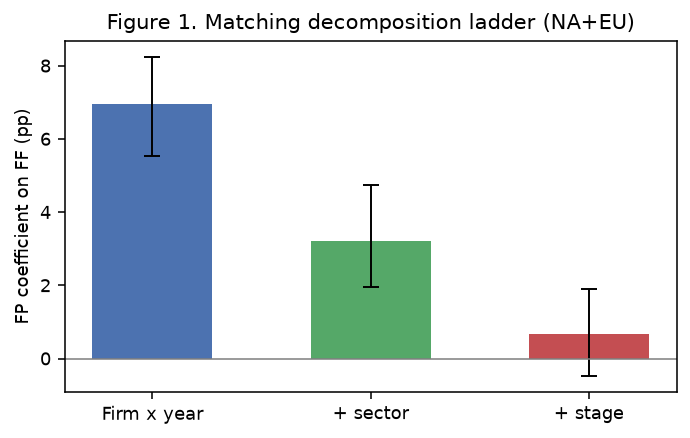

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3.2))
names = ["Firm x year", "+ sector", "+ stage"]
vals = [L["L0_invyear"][0] * 100, L["L1_pluscat"][0] * 100, L["L2_plusstage"][0] * 100]
los = [L[k][1][0] * 100 for k in ("L0_invyear", "L1_pluscat", "L2_plusstage")]
his = [L[k][1][1] * 100 for k in ("L0_invyear", "L1_pluscat", "L2_plusstage")]
ax.bar(names, vals, color=["#4C72B0", "#55A868", "#C44E52"], width=0.55)
ax.errorbar(names, vals, yerr=[np.array(vals) - los, np.array(his) - vals],
            fmt="none", ecolor="black", capsize=4, lw=1)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("FP coefficient on FF (pp)")
ax.set_title("Figure 1. Matching decomposition ladder (NA+EU)")
fig.tight_layout()
fig.savefig(os.path.join(OUT_F, "figure1_ladder.png"))


## Figure 2 — Female-partner arrivals and new-deal composition


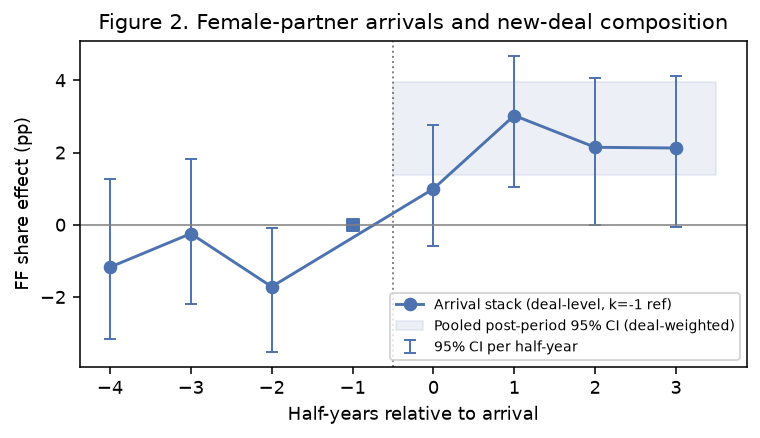

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
pj_ = e11["path_join"]
ks = sorted(int(k) for k in pj_)
ys = [pj_[str(k)] for k in ks]
ks_f = ks[:2] + [-1] + ks[2:] if -1 not in ks else ks
ax.plot([k for k in ks], ys, "o-", color="#4C72B0", label="Arrival stack (deal-level, k=-1 ref)")
pci = e11.get("path_join_ci", {})
if pci:
    ax.errorbar([k for k in ks if str(k) in pci], [pj_[str(k)] for k in ks if str(k) in pci], yerr=[[pj_[str(k)] - pci[str(k)][0] for k in ks if str(k) in pci], [pci[str(k)][1] - pj_[str(k)] for k in ks if str(k) in pci]], fmt="none", ecolor="#4C72B0", capsize=3, lw=1, label="95% CI per half-year")
ax.scatter([-1], [0], color="#4C72B0", marker="s")
ax.axvline(-0.5, color="grey", ls=":", lw=1)
ax.axhline(0, color="grey", lw=0.8)
ax.fill_between([-0.5, 3.5], e11["join"][1][0] * 100, e11["join"][1][1] * 100, color="#4C72B0", alpha=0.10, label="Pooled post-period 95% CI (deal-weighted)")
ax.set_xlabel("Half-years relative to arrival")
ax.set_ylabel("FF share effect (pp)")
ax.set_title("Figure 2. Female-partner arrivals and new-deal composition")
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(OUT_F, "figure2_eventstudy.png"))


## Figure 3 — Female-partner share by stage


figures: figure1-3 saved


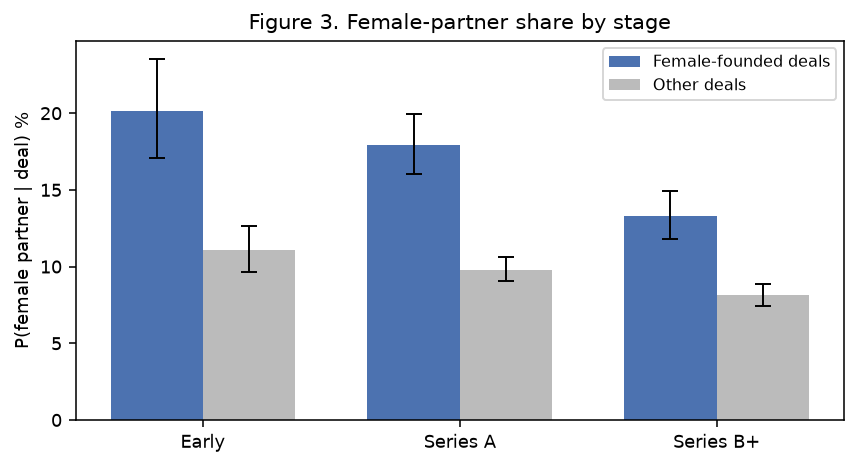

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
x = np.arange(3)
cf = [c for c in e6["p_fp_given_ff"][1]]
ax.bar(x - 0.18, pf, 0.36, label="Female-founded deals", color="#4C72B0")
ax.bar(x + 0.18, pm, 0.36, label="Other deals", color="#BBBBBB")
ax.errorbar(x - 0.18, pf, yerr=[[pf[i] - cf[i][0] * 100 for i in range(3)],
                                [cf[i][1] * 100 - pf[i] for i in range(3)]],
            fmt="none", ecolor="black", capsize=4, lw=1)
cm = [c for c in e6["p_fp_given_mf"][1]]
ax.errorbar(x + 0.18, pm, yerr=[[pm[i] - cm[i][0] * 100 for i in range(3)], [cm[i][1] * 100 - pm[i] for i in range(3)]], fmt="none", ecolor="black", capsize=4, lw=1)
ax.set_xticks(x, ["Early", "Series A", "Series B+"])
ax.set_ylabel("P(female partner | deal) %")
ax.set_title("Figure 3. Female-partner share by stage")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT_F, "figure3_channel.png"))
print("figures: figure1-3 saved")


## Consistency check — regenerated figures versus the paper's figure files
SHA-256 of each PNG just written to `../figures/` against the file attached to the manuscript.


In [ ]:
import hashlib, os
def sha(p): return hashlib.sha256(open(p, "rb").read()).hexdigest()
fails = 0
for n in ["figure1_ladder", "figure2_eventstudy", "figure3_channel"]:
    a, b = sha(os.path.join(OUT_F, n + ".png")), sha(os.path.join("../paper_exhibits/figures", n + ".png"))
    ok = a == b; fails += (not ok); print(f"{n:<18} {'IDENTICAL' if ok else 'DIFFERS'}  sha256 {a[:16]}")
assert fails == 0, f"{fails} figure(s) differ from the paper"
print("\nAll 3 figures are byte-identical to the paper's figure files.")


figure1_ladder     IDENTICAL  sha256 e8326372438c32a3
figure2_eventstudy IDENTICAL  sha256 34169b5158ddfdc2
figure3_channel    IDENTICAL  sha256 863473bd6f8d881b

All 3 figures are byte-identical to the paper's figure files.
